## Modelo Híbrido

# ¿Cómo funciona?

Este notebook combina los dos modelos anteriores para generar recomendaciones más precisas y variadas.

## Idea general

Cada modelo produce un score independiente para cada canción:

- **Content-Based** → score_contenido basado en similitud de audio
- **Collaborative** → score_colaborativo basado en patrones de usuarios similares

Ambos scores se normalizan al rango [0, 1] y se combinan con un peso α:


score_final = α × score_contenido + (1 - α) × score_colaborativo


## Qué hace este notebook

- Carga el modelo SVD guardado en collaborative.ipynb
- Reconstruye el modelo Content-Based desde items.csv
- Combina ambos scores con ponderación ajustable
- Genera recomendaciones finales con título, artista, género y score
- Permite comparar los tres modelos lado a lado

# Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Paths con fallback igual que en los notebooks anteriores
def resolve_path(primary, fallback):
    p = Path(primary)
    return p if p.exists() else Path(fallback)

ITEMS_PATH        = resolve_path('/data/processed/items.csv',          '../../data/processed/items.csv')
INTERACTIONS_PATH = resolve_path('/data/processed/interactions.csv',   '../../data/processed/interactions.csv')
MODEL_SVD_PATH    = resolve_path('/data/processed/modelo_svd.pkl',     '../../data/processed/modelo_svd.pkl')
MODEL_CB_PATH     = resolve_path('/data/processed/modelo_cb.pkl',      '../../data/processed/modelo_cb.pkl')

# Peso del modelo de contenido (0 = solo colaborativo, 1 = solo contenido)
ALPHA = 0.5


# Carga de Datos y Modelos

In [2]:
# Datos
items = pd.read_csv(ITEMS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)

# Consolidar filas duplicadas por ITEM_ID: título/artista = first, género = lista única, popularidad = media
items_indexed = (
    items
    .groupby('ITEM_ID')
    .agg({
        'titulo': 'first',
        'artista': 'first',
        'genero': lambda g: ','.join(sorted(set(g.dropna().astype(str)))),
        'popularidad': 'mean'
    })
    .reset_index()
    .set_index('ITEM_ID')
)

print(f'Canciones: {len(items):,}')
print(f'Interacciones: {len(interactions):,}')

Canciones: 114,000
Interacciones: 750,000


In [3]:
# Modelo colaborativo (guardado por 02_collaborative.ipynb)
with open(MODEL_SVD_PATH, 'rb') as f:
    modelo_svd = pickle.load(f)

user_to_idx = modelo_svd['user_to_idx']
item_to_idx = modelo_svd['item_to_idx']
idx_to_item = modelo_svd['idx_to_item']

U = modelo_svd.get('U', modelo_svd.get('U_train'))
S = modelo_svd.get('S', modelo_svd.get('S_train'))
Vt = modelo_svd.get('Vt', modelo_svd.get('Vt_train'))
media_usuarios = modelo_svd.get('media_usuarios', modelo_svd.get('media_u_train'))
factores_usuario = modelo_svd.get('factores_usuario', modelo_svd.get('factores_usuario_train'))  # U × Σ

print('Modelo SVD cargado')
print(f'Usuarios en el modelo: {len(user_to_idx):,}')
print(f'Canciones en el modelo: {len(item_to_idx):,}')

Modelo SVD cargado
Usuarios en el modelo: 15,000
Canciones en el modelo: 89,639


# Carga del modelo Content-Based


In [4]:
# Cargar el modelo content-based guardado por content_based.ipynb
with open(MODEL_CB_PATH, 'rb') as f:
    modelo_cb = pickle.load(f)

feature_matrix  = modelo_cb['feature_matrix']
item_ids_list   = modelo_cb['item_ids']
cb_item_to_idx  = modelo_cb['item_to_idx']
AUDIO_FEATURES  = modelo_cb['audio_features']

print('Modelo content-based cargado')
print(f'  feature_matrix: {feature_matrix.shape}')
print(f'  items indexados: {len(item_ids_list):,}')
print(f'  audio features: {AUDIO_FEATURES}')


Modelo content-based cargado
  feature_matrix: (89741, 9)
  items indexados: 89,741
  audio features: ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness_norm', 'tempo_norm']


# Funciones de Recomendación

In [5]:
def scores_content_based(user_id: str) -> np.ndarray:
    """
    Calcula el score de similitud de coseno entre el perfil
    de audio del usuario y todas las canciones.
    Retorna un array de shape (n_canciones_items,)
    """
    likes = interactions[
        (interactions['USER_ID'] == user_id) &
        (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()

    if not likes:
        # Fallback: usar plays si no tiene likes
        likes = interactions[
            (interactions['USER_ID'] == user_id) &
            (interactions['EVENT_TYPE'] == 'play')
        ]['ITEM_ID'].tolist()

    if not likes:
        return np.zeros(len(item_ids_list))

    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    perfil  = np.asarray(feature_matrix[indices].mean(axis=0)).ravel().reshape(1, -1)
    return cosine_similarity(perfil, feature_matrix).flatten()


def scores_collaborative(user_id: str) -> np.ndarray:
    """
    Calcula el rating predicho por SVD para todas las canciones del modelo.
    Retorna un array de shape (n_canciones_modelo,)
    """
    if user_id not in user_to_idx:
        return np.zeros(len(item_to_idx))

    u_idx = user_to_idx[user_id]
    # factores_usuario[u] @ Vt reproduce la fila del usuario sin materializar R_pred completa
    return factores_usuario[u_idx] @ Vt + media_usuarios[u_idx]


def normalizar(arr: np.ndarray) -> np.ndarray:
    """Normaliza un array al rango [0, 1]."""
    min_v, max_v = arr.min(), arr.max()
    if max_v == min_v:
        return np.zeros_like(arr)
    return (arr - min_v) / (max_v - min_v)


print('Funciones de scoring definidas')

Funciones de scoring definidas


In [6]:
def recomendar_hibrido(user_id: str, n: int = 10, alpha: float = ALPHA, max_por_artista: int = 1, max_por_genero: int = 2) -> pd.DataFrame:
    """
    Recomienda las N mejores canciones combinando Content-Based y Collaborative.

    Parámetros:
        user_id : ID del usuario
        n       : número de recomendaciones
        alpha   : peso del score de contenido (0=solo collab, 1=solo content)
        max_por_artista : máximo de canciones por artista en el top-N
        max_por_genero : máximo de apariciones por género en el top-N

    Retorna:
        DataFrame con columnas: ITEM_ID, titulo, artista, genero, popularidad,
                                score_contenido, score_colaborativo, score_final
    """
    # Canciones ya escuchadas por el usuario
    ya_vistas = set(interactions[interactions['USER_ID'] == user_id]['ITEM_ID'].tolist())

    # Content-Based 
    sc_raw = scores_content_based(user_id)
    # array sobre items.csv
    sc_norm = normalizar(sc_raw)

    #  Collaborative 
    scol_raw  = scores_collaborative(user_id)
    # array sobre canciones del modelo
    scol_norm = normalizar(scol_raw)

    # Combinar en un DataFrame común 
    # Content-based cubre todos los items; collaborative solo los que vio en entrenamiento
    df_cb = pd.DataFrame({
        'ITEM_ID'           : item_ids_list,
        'score_contenido'   : sc_norm
    })

    df_col = pd.DataFrame({
        'ITEM_ID'             : [idx_to_item[i] for i in range(len(scol_norm))],
        'score_colaborativo'  : scol_norm
    })

    df = df_cb.merge(df_col, on='ITEM_ID', how='left')
    df['score_colaborativo'] = df['score_colaborativo'].fillna(0)

    # Score final 
    df['score_final'] = alpha * df['score_contenido'] + (1 - alpha) * df['score_colaborativo']

    # Excluir ya vistas y ordenar 
    df = df[~df['ITEM_ID'].isin(ya_vistas)]
    df = df.sort_values('score_final', ascending=False)

    # Traer metadata antes del re-ranking para tener acceso a artista/título/género
    meta = items_indexed[['titulo', 'artista', 'genero', 'popularidad']].reset_index()
    df = df.merge(meta, on='ITEM_ID', how='left')

    # Re-ranking simple para evitar que un mismo artista monopolice el top-N
    seleccionados = []
    contador_artistas = {}
    contador_generos = {}
    for _, fila in df.iterrows():
        artista = fila['artista']
        generos_fila = [g.strip() for g in str(fila['genero']).split(',') if g.strip()]
        contador_artistas[artista] = contador_artistas.get(artista, 0)
        puede_agregar = contador_artistas[artista] < max_por_artista
        if puede_agregar and generos_fila:
            for genero in generos_fila:
                if contador_generos.get(genero, 0) >= max_por_genero:
                    puede_agregar = False
                    break
        if puede_agregar:
            seleccionados.append(fila)
            contador_artistas[artista] += 1
            for genero in generos_fila:
                contador_generos[genero] = contador_generos.get(genero, 0) + 1
        if len(seleccionados) == n:
            break

    # Si el filtro deja menos de n resultados, completar sin restricción
    if len(seleccionados) < n:
        faltantes = n - len(seleccionados)
        restantes = df[~df['ITEM_ID'].isin([x['ITEM_ID'] for x in seleccionados])].head(faltantes)
        seleccionados.extend(restantes.to_dict('records'))

    resultado = pd.DataFrame(seleccionados).head(n)

    cols = ['ITEM_ID', 'titulo', 'artista', 'genero', 'popularidad',
            'score_contenido', 'score_colaborativo', 'score_final']
    return resultado[cols].reset_index(drop=True)


print('Función recomendar_hibrido() definida')

Función recomendar_hibrido() definida


# Prueba con Usuario Real

In [9]:
# Usuario con más likes para una prueba representativa
usuario_prueba = interactions[
    interactions['EVENT_TYPE'] == 'like'
]['USER_ID'].value_counts().index[0]

likes = interactions[
    (interactions['USER_ID'] == usuario_prueba) &
    (interactions['EVENT_TYPE'] == 'like')
]['ITEM_ID'].tolist()

print(f'Usuario de prueba: {usuario_prueba} ({len(likes)} likes)')
print('\nSus likes:')
items_indexed.loc[
    [i for i in likes[:5] if i in items_indexed.index],
    ['titulo', 'artista', 'genero']
]

Usuario de prueba: user_4558 (36 likes)

Sus likes:


,titulo,artista,genero
ITEM_ID,,,
3jwcudvYIksoAjU0x6gagd,Valerie,Steve Winwood,"country,folk,singer-songwriter,songwriter"
7tCL3GNUc04W2S7Cx1MzId,Serene Rain,Deep Sleep Rain Sounds,sleep
1wrSlSMgdb4STao5UKN5ML,Rough Day,Rain Sounds,sleep
76CSHuHKMJxmjmdrNBX2Z3,Victoria’s Secret,Jax,"singer-songwriter,songwriter"
1kJvdhrr9MHOZ1e1PhTXTG,Drown,Prateek Kuhad,"folk,indie-pop,singer-songwriter,songwriter"


In [8]:
recomendaciones = recomendar_hibrido(usuario_prueba, n=10, alpha=ALPHA)
print(f'Top 10 recomendaciones híbridas para {usuario_prueba} (α={ALPHA}):')
recomendaciones

Top 10 recomendaciones híbridas para user_4558 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,...",51.0,0.904744,0.538625,0.721685
1,69zxopckIPTya73oBGdE2v,Nit Nit - Lofi Version,Jasleen Royal;Fresh Talent Studios,"singer-songwriter,songwriter",34.0,0.962807,0.406307,0.684557
2,6qMcBfQ3Dy3Cn6q27tcQDR,"Goodbye - Theme from Dark, a Netflix Original ...",Apparat,"ambient,electronic",40.0,0.979357,0.311411,0.645384
3,1JGW1e2tacnCgBPfRH0haY,Bird of Paradise,Snowy White,british,55.0,1.000000,0.286897,0.643448
4,0vINSp4xFZyj9NrQvoCC2d,Waiting For The Symphony,Night Moves,psych-rock,26.0,0.992549,0.291739,0.642144
5,0bCgcTDkZ1RhguEeuUhZ9k,Aesthetic Girl,Yusei,"chill,sad",54.0,0.964790,0.318209,0.641500
6,7kM4yhMogdpiOZu0wL1UFy,Amerikha Expressa,BaianaSystem,afrobeat,28.0,0.990387,0.291622,0.641004
7,63OFKbMaZSDZ4wtesuuq6f,Born To Be Wild,Steppenwolf,"blues,country,folk,hard-rock,metal,psych-rock",73.0,0.909351,0.369994,0.639673
8,3v0krJCUzAT1K32SCnVO98,Highlight - Live,Faber,german,42.0,0.985520,0.291144,0.638332
9,0wY6Zaxswug2Wb9JZZ2HLv,DELETE SOUL,ALEX;TOKYO ROSE;THE AKUMA,club,39.0,0.984787,0.290075,0.637431


# Comparación entre modelos

In [10]:
# Recomendaciones de cada modelo por separado
solo_content = recomendar_hibrido(usuario_prueba, n=10, alpha=1.0)
solo_collab  = recomendar_hibrido(usuario_prueba, n=10, alpha=0.0)
hibrido      = recomendar_hibrido(usuario_prueba, n=10, alpha=0.5)

def estilo_tabla(df):
    return (
        df.style
        .hide(axis='index')
        .format({
            'score_contenido': '{:.3f}',
            'score_colaborativo': '{:.3f}',
            'score_final': '{:.3f}',
            'popularidad': '{:.1f}'
        })
        .background_gradient(subset=['score_final'], cmap='Blues')
        .set_properties(**{'text-align': 'left'})
    )

print('── Solo Content-Based (α=1.0) ──')
display(estilo_tabla(solo_content))

print('\n── Solo Collaborative (α=0.0) ──')
display(estilo_tabla(solo_collab))

print('\n── Híbrido (α=0.5) ──')
display(estilo_tabla(hibrido))

── Solo Content-Based (α=1.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
1JGW1e2tacnCgBPfRH0haY,Bird of Paradise,Snowy White,british,55.0,1.000,0.287,1.000
0vINSp4xFZyj9NrQvoCC2d,Waiting For The Symphony,Night Moves,psych-rock,26.0,0.993,0.292,0.993
7kM4yhMogdpiOZu0wL1UFy,Amerikha Expressa,BaianaSystem,afrobeat,28.0,0.990,0.292,0.990
3v0krJCUzAT1K32SCnVO98,Highlight - Live,Faber,german,42.0,0.986,0.291,0.986
0wY6Zaxswug2Wb9JZZ2HLv,DELETE SOUL,ALEX;TOKYO ROSE;THE AKUMA,club,39.0,0.985,0.290,0.985
6ggA962ctXjQA5PZYUM3i6,Let it Be Known,The Growlers,garage,26.0,0.985,0.287,0.985
3dC3qhF7T9fsfBpLVeZqcf,All for Money,Greensky Bluegrass,bluegrass,27.0,0.982,0.289,0.982
5e0wGPEIDVmhPMYFkzzDkn,Golden Vibe,Beatnugget,study,29.0,0.982,0.289,0.982
34DpOSd0pXWxUgFHA6HhJ0,Aurora,Zero 7;José González,trip-hop,41.0,0.981,0.276,0.981
4yQCgQVUIRBUnLdmXtZ0bo,Winter Time,Steve Miller Band,psych-rock,51.0,0.980,0.290,0.980



── Solo Collaborative (α=0.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0T7DQlfcadEUEjxoHeQQaL,Labios Rotos - En Vivo,Zoé,"alt-rock,alternative,indie,latin,rock",0.0,0.648,0.555,0.555
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.905,0.539,0.539
4aqS25F3ywJ9TGnNkOqilC,Abracadabra - Remastered 2017,Steve Miller Band,"blues,country,folk,hard-rock,psych-rock,singer-songwriter,songwriter",2.3,0.568,0.479,0.479
5t9YU2mww4eiFCeTBy3EFU,One More Round (Free Fire Booyah Day Theme Song),KSHMR;Jeremy Oceans,"edm,electro,house,indian,progressive-house",53.0,0.600,0.452,0.452
3aTJREDBpFWYhR5m4i48jO,Inevitavelmente,Maneva,"brazil,r-n-b,reggae",46.7,0.726,0.400,0.400
7b3OfGX7LuIyTBk6FMdagF,Teardrinker,Mastodon,"alt-rock,groove,hard-rock,metal",0.0,0.637,0.399,0.399
5y0nMZC5kF6uLYaLc97mSo,Loco Contigo,DJ Snake;J Balvin;Tyga,"dance,edm,electro,electronic",0.0,0.677,0.371,0.371
1NzcfWIiD1SnRnqkzT2lfD,Dime A Ve,Jhayco,"latin,latino,reggae,reggaeton",0.0,0.645,0.360,0.360
3sjiHBkn28c9FDyasXJqZf,my girl,Shiloh Dynasty;Shiloh Beat,"chill,sad",55.0,0.901,0.354,0.354
5YfYbZ4bgXC7iBzeVCR8qI,"Something About You - 7"" Version",Level 42,"disco,funk,r-n-b,synth-pop",0.0,0.548,0.352,0.352



── Híbrido (α=0.5) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.905,0.539,0.722
69zxopckIPTya73oBGdE2v,Nit Nit - Lofi Version,Jasleen Royal;Fresh Talent Studios,"singer-songwriter,songwriter",34.0,0.963,0.406,0.685
6qMcBfQ3Dy3Cn6q27tcQDR,"Goodbye - Theme from Dark, a Netflix Original Series",Apparat,"ambient,electronic",40.0,0.979,0.311,0.645
1JGW1e2tacnCgBPfRH0haY,Bird of Paradise,Snowy White,british,55.0,1.000,0.287,0.643
0vINSp4xFZyj9NrQvoCC2d,Waiting For The Symphony,Night Moves,psych-rock,26.0,0.993,0.292,0.642
0bCgcTDkZ1RhguEeuUhZ9k,Aesthetic Girl,Yusei,"chill,sad",54.0,0.965,0.318,0.641
7kM4yhMogdpiOZu0wL1UFy,Amerikha Expressa,BaianaSystem,afrobeat,28.0,0.990,0.292,0.641
63OFKbMaZSDZ4wtesuuq6f,Born To Be Wild,Steppenwolf,"blues,country,folk,hard-rock,metal,psych-rock",73.0,0.909,0.370,0.640
3v0krJCUzAT1K32SCnVO98,Highlight - Live,Faber,german,42.0,0.986,0.291,0.638
0wY6Zaxswug2Wb9JZZ2HLv,DELETE SOUL,ALEX;TOKYO ROSE;THE AKUMA,club,39.0,0.985,0.290,0.637


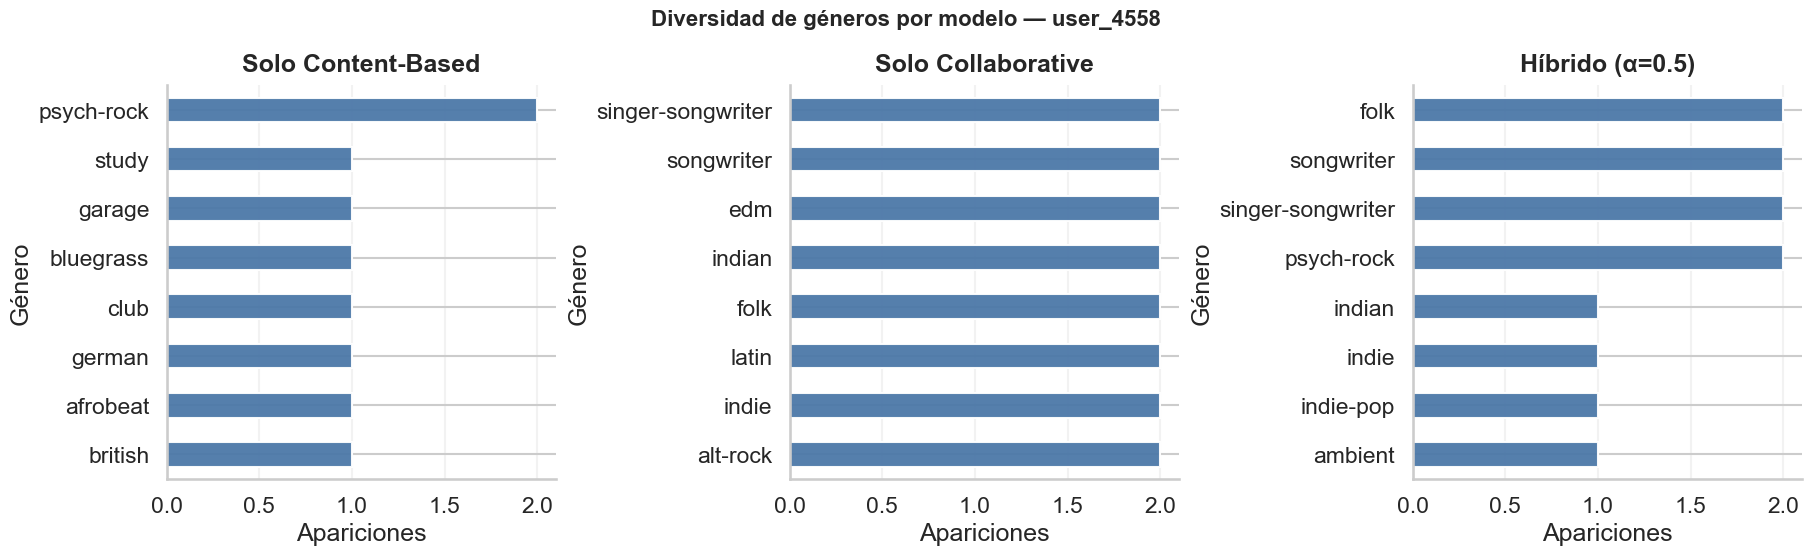

In [11]:
# Diversidad de géneros por modelo
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (titulo, df) in zip(axes, [
    ('Solo Content-Based', solo_content),
    ('Solo Collaborative', solo_collab),
    ('Híbrido (α=0.5)',    hibrido)
]):
    generos = (
        df['genero']
        .fillna('')
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
    )
    generos = generos[generos != '']
    top_generos = generos.value_counts().head(8)
    top_generos.sort_values().plot(kind='barh', ax=ax, color='#4C78A8', edgecolor='white', alpha=0.95)
    ax.set_title(titulo, pad=10, fontweight='bold')
    ax.set_xlabel('Apariciones')
    ax.set_ylabel('Género')
    ax.grid(axis='x', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(f'Diversidad de géneros por modelo — {usuario_prueba}', y=1.08, fontsize=16, fontweight='bold')
plt.show()

# Efecto de α en las Recomendaciones

In [12]:
# Ver cómo cambia el score_final según alpha
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

print(f'Top 5 canciones para {usuario_prueba} según α:\n')
print(f'{"Canción":<35} {" | ".join([f"α={a}" for a in alphas])}')
print('-' * 80)

for a in alphas:
    top5 = recomendar_hibrido(usuario_prueba, n=5, alpha=a)
    print(f'\nα = {a}')
    print(top5[['titulo', 'genero', 'score_final']].to_string(index=False))

Top 5 canciones para user_4558 según α:

Canción                             α=0.0 | α=0.25 | α=0.5 | α=0.75 | α=1.0
--------------------------------------------------------------------------------

α = 0.0
                                          titulo                                                               genero  score_final
                          Labios Rotos - En Vivo                                alt-rock,alternative,indie,latin,rock     0.555193
                                           Kadam             folk,indian,indie,indie-pop,singer-songwriter,songwriter     0.538625
                   Abracadabra - Remastered 2017 blues,country,folk,hard-rock,psych-rock,singer-songwriter,songwriter     0.478823
One More Round (Free Fire Booyah Day Theme Song)                           edm,electro,house,indian,progressive-house     0.452157
                                 Inevitavelmente                                                  brazil,r-n-b,reggae     0.399883

α = 0.

# Prueba con cualquier usuario

In [13]:
USER_ID_PRUEBA    = 'user_5001'
N_RECOMENDACIONES = 5
ALPHA_PRUEBA      = 0.5

resultado = recomendar_hibrido(USER_ID_PRUEBA, n=N_RECOMENDACIONES, alpha=ALPHA_PRUEBA)
print(f'Recomendaciones híbridas para {USER_ID_PRUEBA} (α={ALPHA_PRUEBA}):')
resultado

Recomendaciones híbridas para user_5001 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,2Ey6v4Sekh3Z0RUSISRosD,Layla,Derek & The Dominos,"blues,british,country,folk,hard-rock,psych-roc...",0.0,0.963743,1.000000,0.981872
1,5TuTzdZVv2k4Gtl7Rn6pow,Lamento Boliviano,Los Enanitos Verdes,"alt-rock,alternative,latin,rock,ska",0.0,0.986094,0.814198,0.900146
2,7y5uK11sbFNiNEafUvntSL,Dragula,Rob Zombie,"alt-rock,alternative,hard-rock,industrial,metal",0.0,0.970455,0.797977,0.884216
3,2Zlqc4m6Gv0tSsgDS87LJQ,Ley Seca,Jhayco;Anuel AA,"latin,latino,reggae,reggaeton",0.5,0.992198,0.767742,0.879970
4,54zCdkbIALAnv8Ihi3XWlD,Stay Alive,José González,"folk,goth,indie,indie-pop,singer-songwriter,so...",0.0,0.857949,0.869134,0.863542


In [14]:
import pickle, os

MODEL_HYBRID_PATH = '../../data/processed/modelo_hybrid.pkl'
os.makedirs(os.path.dirname(MODEL_HYBRID_PATH), exist_ok=True)

modelo_hybrid = {
    # ── Collaborative (SVD) ──────────────────────────────────────────
    'user_to_idx':      user_to_idx,
    'item_to_idx':      item_to_idx,
    'idx_to_item':      idx_to_item,
    'factores_usuario': factores_usuario,
    'Vt':               Vt,
    'media_usuarios':   media_usuarios,
    # ── Content-Based ────────────────────────────────────────────────
    'feature_matrix':   feature_matrix,
    'item_ids':         item_ids_list,
    'cb_item_to_idx':   cb_item_to_idx,
    'audio_features':   AUDIO_FEATURES,
    # ── Híbrido ──────────────────────────────────────────────────────
    'alpha':            ALPHA,
}

with open(MODEL_HYBRID_PATH, 'wb') as f:
    pickle.dump(modelo_hybrid, f)

print(f'Modelo híbrido guardado en: {MODEL_HYBRID_PATH}')
print(f'  Usuarios:  {len(user_to_idx):,}')
print(f'  Items SVD: {len(item_to_idx):,}')
print(f'  Items CB:  {feature_matrix.shape[0]:,}')
print(f'  Alpha:     {ALPHA}')


Modelo híbrido guardado en: ../../data/processed/modelo_hybrid.pkl
  Usuarios:  15,000
  Items SVD: 89,639
  Items CB:  89,741
  Alpha:     0.5
